# Energy Forecasting — Baselines, SARIMA/SARIMAX, LSTM, N-BEATS and Hybrid Residual NN

Notebook adaptado do teu `neural_network_models.ipynb`.

Inclui:
- Baselines: Naive, Seasonal Naive, Rolling Mean, Ridge, Random Forest
- SARIMA
- SARIMAX com features exógenas
- LSTM
- N-BEATS simplificado em PyTorch
- Híbrido proposto: `Seasonal Naive + Neural Network nos resíduos`

Features esperadas/reaproveitadas:
`is_weekend, day_of_week, day_name, month, month_name, quarter, week_of_year, is_holiday_pt, is_bridge_day, lag_1d, lag_7d, lag_14d, lag_30d, roll7_mean, roll7_std, roll30_mean, roll7_ratio, wow_change, dod_change, zscore_municipality, pct_rank_global, log_kwh, kwh_per_user`.


In [68]:
# 0. Imports and config
import warnings, random, gc, math
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Turn off while testing if it is too heavy
RUN_SARIMA = True
RUN_SARIMAX = True
RUN_LSTM = True
RUN_NBEATS = True
RUN_HYBRID = True

EPOCHS = 80
BATCH_SIZE = 64
PATIENCE = 12
SEQ_LENGTH = 30
FORECAST_SEASONAL_PERIOD = 365  # diário: 7 semanal; muda para 365 para yearly seasonal naive
SARIMA_SEASONAL_PERIOD = 7     # 365 fica muito pesado em SARIMA/SARIMAX


Device: cpu


## 1. Load data

Altera `DATA_PATH` para o teu CSV. O notebook tenta detetar automaticamente:
- target: `kwh_per_user`, `avg_kwh`, `kWh`, `kwh`
- grupo: `municipality`, `_source_folder`, `user_id`, `id`


In [69]:
BASE_PATH = Path(r'C:/Users/GONCA/Desktop/Iscte/MCD/Theses')
DATA_PATH = BASE_PATH / 'municipality_daily_consumption.csv'

DATE_COL = 'date'
TARGET_CANDIDATES = ['avg_kwh_per_user', 'avg_kwh', 'kWh', 'kwh']
GROUP_CANDIDATES = ['municipality', '_source_folder', 'user_id', 'id']

def pick_first_existing(columns, candidates, label):
    for c in candidates:
        if c in columns:
            return c
    raise ValueError(f'Could not find {label}. Tried: {candidates}')

df_raw = pd.read_csv(DATA_PATH)
df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL])
df_raw = df_raw.sort_values(DATE_COL).reset_index(drop=True)

TARGET_COL = pick_first_existing(df_raw.columns, TARGET_CANDIDATES, 'target column')
GROUP_COL = pick_first_existing(df_raw.columns, GROUP_CANDIDATES, 'group column')

print('Shape:', df_raw.shape)
print('Date range:', df_raw[DATE_COL].min().date(), '→', df_raw[DATE_COL].max().date())
print('Target:', TARGET_COL)
print('Group:', GROUP_COL)
display(df_raw.head())


Shape: (115144, 5)
Date range: 2014-11-04 → 2022-06-08
Target: avg_kwh
Group: municipality


,municipality,date,avg_kwh,std_kwh,n_users
0,Santander,2014-11-04,0.138348,0.155339,3
1,Santander,2014-11-05,0.218616,0.202234,4
2,Santander,2014-11-06,0.184656,0.145579,4
3,Santander,2014-11-07,0.198615,0.154671,4
4,Santander,2014-11-08,0.152052,0.135469,4


## 2. Feature engineering

Se as colunas já existirem, são mantidas. Se faltarem, são criadas quando possível.

In [70]:
FEATURE_COLUMNS_REQUESTED = [
    'is_weekend', 'day_of_week', 'month', 'quarter', 'week_of_year',
    'is_holiday_pt', 'is_bridge_day',
    'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d',
    'roll7_mean', 'roll7_std', 'roll30_mean', 'roll7_ratio',
    'wow_change', 'dod_change',
    'zscore_municipality', 'pct_rank_global', 'log_kwh', 'avg_kwh_per_user'
]

def add_calendar_features(df):
    df = df.copy()
    df['day_of_week'] = df[DATE_COL].dt.dayofweek
    df['day_name'] = df[DATE_COL].dt.day_name()
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['month'] = df[DATE_COL].dt.month
    df['month_name'] = df[DATE_COL].dt.month_name()
    df['quarter'] = df[DATE_COL].dt.quarter
    df['week_of_year'] = df[DATE_COL].dt.isocalendar().week.astype(int)
    return df

def add_pt_holidays(df):
    df = df.copy()
    try:
        import holidays
        years = sorted(df[DATE_COL].dt.year.unique())
        pt_holidays = holidays.country_holidays('PT', years=years)
        holiday_dates = set(pd.to_datetime(list(pt_holidays.keys())))
        df['is_holiday_pt'] = df[DATE_COL].isin(holiday_dates).astype(int)
        next_day = df[DATE_COL] + pd.Timedelta(days=1)
        prev_day = df[DATE_COL] - pd.Timedelta(days=1)
        df['is_bridge_day'] = (
            ((df[DATE_COL].dt.dayofweek == 0) & next_day.isin(holiday_dates)) |
            ((df[DATE_COL].dt.dayofweek == 4) & prev_day.isin(holiday_dates))
        ).astype(int)
    except Exception:
        df['is_holiday_pt'] = df.get('is_holiday_pt', 0)
        df['is_bridge_day'] = df.get('is_bridge_day', 0)
    return df

def add_lags_rollings(df, target_col, group_col):
    df = df.sort_values([group_col, DATE_COL]).copy()
    g = df.groupby(group_col, group_keys=False)[target_col]

    for lag in [1, 7, 14, 30]:
        col = f'lag_{lag}d'
        if col not in df.columns:
            df[col] = g.shift(lag)

    if 'roll7_mean' not in df.columns:
        df['roll7_mean'] = g.shift(1).rolling(7, min_periods=1).mean().reset_index(level=0, drop=True)
    if 'roll7_std' not in df.columns:
        df['roll7_std'] = g.shift(1).rolling(7, min_periods=2).std().reset_index(level=0, drop=True)
    if 'roll30_mean' not in df.columns:
        df['roll30_mean'] = g.shift(1).rolling(30, min_periods=1).mean().reset_index(level=0, drop=True)
    if 'roll7_ratio' not in df.columns:
        df['roll7_ratio'] = df['lag_1d'] / df['roll7_mean'].replace(0, np.nan)
    if 'wow_change' not in df.columns:
        df['wow_change'] = (df['lag_1d'] - df['lag_7d']) / df['lag_7d'].replace(0, np.nan)
    if 'dod_change' not in df.columns:
        lag_2d = g.shift(2)
        df['dod_change'] = (df['lag_1d'] - lag_2d) / lag_2d.replace(0, np.nan)
    if 'zscore_municipality' not in df.columns:
        exp_mean = g.expanding(min_periods=30).mean().shift(1).reset_index(level=0, drop=True)
        exp_std = g.expanding(min_periods=30).std().shift(1).reset_index(level=0, drop=True)
        df['zscore_municipality'] = (df[target_col] - exp_mean) / exp_std.replace(0, np.nan)
    if 'pct_rank_global' not in df.columns:
        df['pct_rank_global'] = df.groupby(DATE_COL)[target_col].rank(pct=True)
    if 'log_kwh' not in df.columns:
        df['log_kwh'] = np.log1p(df[target_col].clip(lower=0))
    return df

df = add_calendar_features(df_raw)
df = add_pt_holidays(df)
df = add_lags_rollings(df, TARGET_COL, GROUP_COL)
df = df.replace([np.inf, -np.inf], np.nan)

# Encode names
cat_cols = [c for c in ['day_name', 'month_name'] if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

feature_cols = [c for c in FEATURE_COLUMNS_REQUESTED if c in df.columns and c != TARGET_COL]
feature_cols += [c for c in df.columns if c.startswith('day_name_') or c.startswith('month_name_')]
feature_cols = sorted(set(feature_cols))

# avoid same-day leakage if target is another kwh column
if 'avg_kwh_per_user' in feature_cols and TARGET_COL != 'avg_kwh_per_user':
    feature_cols.remove('avg_kwh_per_user')

print('Number of features:', len(feature_cols))
print(feature_cols)


Number of features: 39
['day_name_Friday', 'day_name_Monday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday', 'day_of_week', 'dod_change', 'is_bridge_day', 'is_holiday_pt', 'is_weekend', 'lag_14d', 'lag_1d', 'lag_30d', 'lag_7d', 'log_kwh', 'month', 'month_name_April', 'month_name_August', 'month_name_December', 'month_name_February', 'month_name_January', 'month_name_July', 'month_name_June', 'month_name_March', 'month_name_May', 'month_name_November', 'month_name_October', 'month_name_September', 'pct_rank_global', 'quarter', 'roll30_mean', 'roll7_mean', 'roll7_ratio', 'roll7_std', 'week_of_year', 'wow_change', 'zscore_municipality']


## 3. Select groups and split

In [71]:
MIN_OBSERVATIONS = 365
N_GROUPS = 3

valid_groups = df.groupby(GROUP_COL).size().sort_values(ascending=False)
valid_groups = valid_groups[valid_groups >= MIN_OBSERVATIONS]
# GROUPS_TO_FORECAST = valid_groups.head(N_GROUPS).index.tolist()
# Manual example:
GROUPS_TO_FORECAST = ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']

print('Groups selected:', GROUPS_TO_FORECAST)

def make_daily_group_frame(df, group_value):
    part = df[df[GROUP_COL] == group_value].sort_values(DATE_COL).copy().set_index(DATE_COL)
    full_idx = pd.date_range(part.index.min(), part.index.max(), freq='D')
    part = part.reindex(full_idx)
    part.index.name = DATE_COL
    part[GROUP_COL] = group_value
    part[TARGET_COL] = part[TARGET_COL].interpolate('linear').ffill().bfill()
    for c in feature_cols:
        if c not in part.columns:
            part[c] = np.nan
        part[c] = part[c].ffill().bfill()
        part[c] = part[c].fillna(part[c].median() if pd.api.types.is_numeric_dtype(part[c]) else 0)
    return part[[GROUP_COL, TARGET_COL] + feature_cols]

def time_split(part, train_ratio=0.70, val_ratio=0.15):
    n = len(part)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return part.iloc[:train_end].copy(), part.iloc[train_end:val_end].copy(), part.iloc[val_end:].copy()

series_data = {}
for group in GROUPS_TO_FORECAST:
    part = make_daily_group_frame(df, group)
    train, val, test = time_split(part)
    series_data[group] = {'full': part, 'train': train, 'val': val, 'test': test}
    print(f'\n{group}')
    print(f'  train: {train.index.min().date()} → {train.index.max().date()} | {len(train)}')
    print(f'  val:   {val.index.min().date()} → {val.index.max().date()} | {len(val)}')
    print(f'  test:  {test.index.min().date()} → {test.index.max().date()} | {len(test)}')


Groups selected: ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']

Vitoria-Gasteiz
  train: 2017-01-07 → 2020-10-20 | 1383
  val:   2020-10-21 → 2021-08-12 | 296
  test:  2021-08-13 → 2022-06-05 | 297

Donostia/San Sebastian
  train: 2017-01-24 → 2020-10-25 | 1371
  val:   2020-10-26 → 2021-08-15 | 294
  test:  2021-08-16 → 2022-06-05 | 294

Pamplona/Iruna
  train: 2017-05-29 → 2020-12-01 | 1283
  val:   2020-12-02 → 2021-09-02 | 275
  test:  2021-09-03 → 2022-06-05 | 276


## 4. Metrics and helpers

In [72]:
all_results = {g: {} for g in GROUPS_TO_FORECAST}

def evaluate_model(actual, predicted, model_name):
    actual = pd.Series(actual).astype(float)
    predicted = pd.Series(predicted, index=actual.index).astype(float)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.nanmean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    smape = np.nanmean(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)).replace(0, np.nan)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'sMAPE(%)': smape}

def save_result(group, model_name, actual, pred, extra=None):
    metrics = evaluate_model(actual, pred, model_name)
    all_results[group][model_name] = {
        'pred': pd.Series(pred, index=actual.index),
        'metrics': metrics,
        'extra': extra or {}
    }
    return metrics

def seasonal_naive_forecast(history, horizon_index, period=7):
    history = pd.Series(history).copy()
    preds = []
    for date in horizon_index:
        candidate = date - pd.Timedelta(days=period)
        preds.append(history.loc[candidate] if candidate in history.index else history.tail(period).mean())
    return pd.Series(preds, index=horizon_index)


## 5. Baselines

In [73]:
for group in GROUPS_TO_FORECAST:
    print(f'\n{"="*80}\nBASELINES — {group}\n{"="*80}')
    train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
    train_val = pd.concat([train, val])
    y_train_val = train_val[TARGET_COL]
    y_test = test[TARGET_COL]

    naive_pred = pd.Series(y_train_val.iloc[-1], index=y_test.index)
    seasonal_pred = seasonal_naive_forecast(y_train_val, y_test.index, period=FORECAST_SEASONAL_PERIOD)
    rolling7_pred = pd.Series(y_train_val.tail(7).mean(), index=y_test.index)

    rows = [
        save_result(group, 'Naive', y_test, naive_pred),
        save_result(group, f'Seasonal Naive ({FORECAST_SEASONAL_PERIOD}d)', y_test, seasonal_pred),
        save_result(group, 'Rolling Mean (7d)', y_test, rolling7_pred),
    ]

    X_train_val = train_val[feature_cols].astype(float).fillna(0)
    X_test = test[feature_cols].astype(float).fillna(0)

    ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
    ridge.fit(X_train_val, y_train_val)
    rows.append(save_result(group, 'Ridge Features', y_test, pd.Series(ridge.predict(X_test), index=y_test.index)))

    rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=SEED, n_jobs=-1)
    rf.fit(X_train_val, y_train_val)
    rows.append(save_result(group, 'Random Forest Features', y_test, pd.Series(rf.predict(X_test), index=y_test.index)))

    display(pd.DataFrame(rows).set_index('Model').sort_values('RMSE').round(4))



BASELINES — Vitoria-Gasteiz


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0006,0.0018,0.1678,0.1681
Ridge Features,0.0018,0.0026,0.5598,0.5613
Seasonal Naive (365d),0.0344,0.0450,12.3026,11.7859
Naive,0.0986,0.1149,31.2970,38.6875
Rolling Mean (7d),0.1045,0.1205,33.3135,41.6463



BASELINES — Donostia/San Sebastian


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0002,0.0004,0.0551,0.0551
Ridge Features,0.0028,0.0039,0.6984,0.7022
Seasonal Naive (365d),0.0400,0.0523,10.6751,10.3150
Rolling Mean (7d),0.0739,0.0938,17.8335,20.4680
Naive,0.0912,0.1090,22.4008,26.2052



BASELINES — Pamplona/Iruna


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0003,0.0005,0.0635,0.0634
Ridge Features,0.0013,0.0019,0.3446,0.3450
Seasonal Naive (365d),0.0338,0.0473,9.2502,9.7151
Naive,0.0637,0.0820,16.4780,18.7399
Rolling Mean (7d),0.0818,0.0985,21.5065,25.0787


## 6. SARIMA and SARIMAX

In [74]:
if RUN_SARIMA:
    SARIMA_ORDERS = [(1, 1, 1), (2, 1, 1), (1, 1, 2)]
    SARIMA_SEASONAL_ORDERS = [(1, 1, 1, SARIMA_SEASONAL_PERIOD), (0, 1, 1, SARIMA_SEASONAL_PERIOD)]

    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nSARIMA — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
        train_val = pd.concat([train, val])
        y_train_val, y_test = train_val[TARGET_COL].astype(float), test[TARGET_COL].astype(float)
        best = {'rmse': np.inf, 'pred': None, 'params': None}

        for order in SARIMA_ORDERS:
            for s_order in SARIMA_SEASONAL_ORDERS:
                try:
                    model = SARIMAX(y_train_val, order=order, seasonal_order=s_order,
                                    enforce_stationarity=False, enforce_invertibility=False)
                    fitted = model.fit(disp=False, maxiter=150, low_memory=True)
                    pred = pd.Series(fitted.forecast(steps=len(y_test)).values, index=y_test.index)
                    rmse = np.sqrt(mean_squared_error(y_test, pred))
                    if rmse < best['rmse']:
                        best = {'rmse': rmse, 'pred': pred, 'params': (order, s_order)}
                except Exception as e:
                    print(f'Failed {order} {s_order}: {e}')

        if best['pred'] is not None:
            metrics = save_result(group, 'SARIMA', y_test, best['pred'], {'params': best['params']})
            print('Best params:', best['params'])
            display(pd.DataFrame([metrics]).set_index('Model').round(4))

if RUN_SARIMAX:
    SARIMAX_EXOG_COLS = [c for c in [
        'is_weekend', 'day_of_week', 'month', 'quarter', 'week_of_year',
        'is_holiday_pt', 'is_bridge_day', 'lag_1d', 'lag_7d', 'roll7_mean',
        'roll30_mean', 'wow_change', 'dod_change', 'zscore_municipality', 'pct_rank_global'
    ] if c in feature_cols]

    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nSARIMAX — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
        train_val = pd.concat([train, val])
        y_train_val, y_test = train_val[TARGET_COL].astype(float), test[TARGET_COL].astype(float)
        X_train_val = train_val[SARIMAX_EXOG_COLS].astype(float).fillna(0)
        X_test = test[SARIMAX_EXOG_COLS].astype(float).fillna(0)

        try:
            model = SARIMAX(y_train_val, exog=X_train_val, order=(1,1,1),
                            seasonal_order=(1,1,1,SARIMA_SEASONAL_PERIOD),
                            enforce_stationarity=False, enforce_invertibility=False)
            fitted = model.fit(disp=False, maxiter=150, low_memory=True)
            pred = pd.Series(fitted.forecast(steps=len(y_test), exog=X_test).values, index=y_test.index)
            metrics = save_result(group, 'SARIMAX', y_test, pred, {'exog_cols': SARIMAX_EXOG_COLS})
            display(pd.DataFrame([metrics]).set_index('Model').round(4))
        except Exception as e:
            print('SARIMAX failed:', e)



SARIMA — Vitoria-Gasteiz
Best params: ((1, 1, 1), (1, 1, 1, 7))


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMA,0.2487,0.2693,85.3265,139.9368



SARIMA — Donostia/San Sebastian
Failed (2, 1, 1) (1, 1, 1, 7): Input contains NaN.
Failed (2, 1, 1) (0, 1, 1, 7): Input contains NaN.
Best params: ((1, 1, 2), (0, 1, 1, 7))


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMA,0.0845,0.1018,20.8342,24.1426



SARIMA — Pamplona/Iruna
Best params: ((1, 1, 1), (1, 1, 1, 7))


...

,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMAX,0.191,0.2077,65.4414,106.782



SARIMAX — Donostia/San Sebastian


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMAX,0.0226,0.0307,6.6063,6.2084



SARIMAX — Pamplona/Iruna


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
SARIMAX,0.0164,0.02,4.3583,4.4918


## 7. PyTorch utilities

In [75]:
class WindowDataset(Dataset):
    def __init__(self, X, y, seq_length=30):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        self.seq_length = seq_length
    def __len__(self):
        return len(self.y) - self.seq_length
    def __getitem__(self, idx):
        return self.X[idx:idx+self.seq_length], self.y[idx+self.seq_length]

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def make_scaled_xy(train_df, val_df, test_df, cols, target_col):
    x_scaler, y_scaler = StandardScaler(), StandardScaler()
    X_train = x_scaler.fit_transform(train_df[cols].astype(float).fillna(0))
    X_val = x_scaler.transform(val_df[cols].astype(float).fillna(0))
    X_test = x_scaler.transform(test_df[cols].astype(float).fillna(0))
    y_train = y_scaler.fit_transform(train_df[[target_col]].astype(float)).ravel()
    y_val = y_scaler.transform(val_df[[target_col]].astype(float)).ravel()
    y_test = y_scaler.transform(test_df[[target_col]].astype(float)).ravel()
    return X_train, y_train, X_val, y_val, X_test, y_test, x_scaler, y_scaler

def train_torch_model(model, train_loader, val_loader, epochs=80, lr=1e-3, patience=12):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    best_state, best_val, bad = None, np.inf, 0
    for epoch in range(1, epochs+1):
        model.train(); losses=[]
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); losses.append(loss.item())
        model.eval(); vloss=[]
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vloss.append(loss_fn(model(xb), yb).item())
        val_loss = float(np.mean(vloss)) if vloss else np.inf
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | train={np.mean(losses):.5f} | val={val_loss:.5f}')
        if bad >= patience:
            print(f'Early stopping at epoch {epoch}. Best val={best_val:.5f}')
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_windows(model, X_context, y_scaler, index, seq_length=30):
    model.eval()
    dataset = WindowDataset(X_context, np.zeros(len(X_context)), seq_length)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
    preds = np.vstack(preds).ravel()
    preds = y_scaler.inverse_transform(preds.reshape(-1, 1)).ravel()
    return pd.Series(preds, index=index[seq_length:])


## 8. LSTM

In [76]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

if RUN_LSTM:
    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nLSTM — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
        X_train, y_train, X_val, y_val, X_test, _, _, y_scaler = make_scaled_xy(train, val, test, feature_cols, TARGET_COL)
        train_loader = DataLoader(WindowDataset(X_train, y_train, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(WindowDataset(X_val, y_val, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False)
        model = LSTMForecaster(input_size=len(feature_cols))
        model = train_torch_model(model, train_loader, val_loader, EPOCHS, patience=PATIENCE)
        X_context = np.vstack([X_val, X_test])
        context_index = val.index.append(test.index)
        pred = predict_windows(model, X_context, y_scaler, context_index, SEQ_LENGTH).reindex(test.index).dropna()
        actual = test.loc[pred.index, TARGET_COL]
        metrics = save_result(group, 'LSTM', actual, pred)
        display(pd.DataFrame([metrics]).set_index('Model').round(4))
        gc.collect()



LSTM — Vitoria-Gasteiz
Epoch 001 | train=0.69385 | val=2.22557
Epoch 010 | train=0.09458 | val=1.13068
Epoch 020 | train=0.07549 | val=1.18635
Early stopping at epoch 25. Best val=0.85710


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
LSTM,0.0322,0.0432,10.3723,10.8216



LSTM — Donostia/San Sebastian
Epoch 001 | train=0.75697 | val=0.87323
Epoch 010 | train=0.08276 | val=0.26906
Early stopping at epoch 18. Best val=0.17710


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
LSTM,0.0258,0.0347,6.3596,6.6413



LSTM — Pamplona/Iruna
Epoch 001 | train=0.83491 | val=0.46257
Epoch 010 | train=0.11370 | val=0.14241
Epoch 020 | train=0.08295 | val=0.12748
Epoch 030 | train=0.07152 | val=0.11979
Epoch 040 | train=0.06161 | val=0.14547
Early stopping at epoch 44. Best val=0.10943


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
LSTM,0.026,0.0331,7.1957,7.3778


## 9. N-BEATS simplified

In [77]:
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, hidden_size=128, n_layers=4):
        super().__init__()
        layers=[]; n=input_size
        for _ in range(n_layers):
            layers += [nn.Linear(n, hidden_size), nn.ReLU()]
            n = hidden_size
        self.net = nn.Sequential(*layers)
        self.backcast = nn.Linear(hidden_size, input_size)
        self.forecast = nn.Linear(hidden_size, 1)
    def forward(self, x):
        h = self.net(x)
        return self.backcast(h), self.forecast(h)

class SimpleNBeats(nn.Module):
    def __init__(self, input_size=30, n_blocks=3, hidden_size=128):
        super().__init__()
        self.blocks = nn.ModuleList([NBeatsBlock(input_size, hidden_size) for _ in range(n_blocks)])
    def forward(self, x):
        residual = x[:, :, 0]
        forecast = torch.zeros((x.size(0), 1), device=x.device)
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast
        return forecast

if RUN_NBEATS:
    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nN-BEATS — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'].copy(), series_data[group]['val'].copy(), series_data[group]['test'].copy()
        nbeats_cols = [TARGET_COL] + feature_cols
        nbeats_cols = list(dict.fromkeys(nbeats_cols))
        X_train, y_train, X_val, y_val, X_test, _, _, y_scaler = make_scaled_xy(train, val, test, nbeats_cols, TARGET_COL)
        train_loader = DataLoader(WindowDataset(X_train, y_train, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(WindowDataset(X_val, y_val, SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=False)
        model = SimpleNBeats(input_size=SEQ_LENGTH, n_blocks=3, hidden_size=128)
        model = train_torch_model(model, train_loader, val_loader, EPOCHS, patience=PATIENCE)
        X_context = np.vstack([X_val, X_test])
        context_index = val.index.append(test.index)
        pred = predict_windows(model, X_context, y_scaler, context_index, SEQ_LENGTH).reindex(test.index).dropna()
        actual = test.loc[pred.index, TARGET_COL]
        metrics = save_result(group, 'N-BEATS simplified', actual, pred)
        display(pd.DataFrame([metrics]).set_index('Model').round(4))
        gc.collect()



N-BEATS — Vitoria-Gasteiz
Epoch 001 | train=0.33046 | val=0.74910
Epoch 010 | train=0.05431 | val=0.24895
Epoch 020 | train=0.02704 | val=0.47018
Early stopping at epoch 27. Best val=0.22786


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
N-BEATS simplified,0.0147,0.0202,5.1214,5.0691



N-BEATS — Donostia/San Sebastian
Epoch 001 | train=0.26993 | val=0.23448
Epoch 010 | train=0.04208 | val=0.08201
Epoch 020 | train=0.02662 | val=0.07395
Early stopping at epoch 28. Best val=0.06259


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
N-BEATS simplified,0.0145,0.0201,3.6957,3.7209



N-BEATS — Pamplona/Iruna
Epoch 001 | train=0.41451 | val=0.17113
Epoch 010 | train=0.05587 | val=0.09869
Early stopping at epoch 19. Best val=0.09175


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
N-BEATS simplified,0.0172,0.0237,4.8378,4.7813


## 10. Proposed hybrid: Seasonal Naive + Neural Network residual

Formula:

`forecast_t = seasonal_naive_t + residual_nn(features_t)`

The seasonal naive handles the repeated weekly/yearly pattern. The neural network only learns the residual/error left by that baseline.

In [78]:
class ResidualMLP(nn.Module):
    def __init__(self, input_size, hidden_size=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.ReLU(), nn.BatchNorm1d(hidden_size), nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )
    def forward(self, x):
        return self.net(x)

if RUN_HYBRID:
    for group in GROUPS_TO_FORECAST:
        print(f'\n{"="*80}\nHYBRID Seasonal Naive + Residual NN — {group}\n{"="*80}')
        train, val, test = series_data[group]['train'], series_data[group]['val'], series_data[group]['test']
        train_val = pd.concat([train, val])
        full_train_val_y = train_val[TARGET_COL].astype(float)

        seasonal_fitted = full_train_val_y.shift(FORECAST_SEASONAL_PERIOD)
        seasonal_fitted = seasonal_fitted.fillna(full_train_val_y.expanding().mean())
        residuals = full_train_val_y - seasonal_fitted

        x_scaler, r_scaler = StandardScaler(), StandardScaler()
        X_train = x_scaler.fit_transform(train[feature_cols].astype(float).fillna(0))
        X_val = x_scaler.transform(val[feature_cols].astype(float).fillna(0))
        X_test = x_scaler.transform(test[feature_cols].astype(float).fillna(0))
        y_res_train = r_scaler.fit_transform(residuals.loc[train.index].values.reshape(-1,1)).ravel()
        y_res_val = r_scaler.transform(residuals.loc[val.index].values.reshape(-1,1)).ravel()

        train_loader = DataLoader(TabularDataset(X_train, y_res_train), batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(TabularDataset(X_val, y_res_val), batch_size=BATCH_SIZE, shuffle=False)
        model = ResidualMLP(input_size=len(feature_cols))
        model = train_torch_model(model, train_loader, val_loader, EPOCHS, patience=PATIENCE)

        seasonal_test = seasonal_naive_forecast(full_train_val_y, test.index, period=FORECAST_SEASONAL_PERIOD)
        model.eval()
        with torch.no_grad():
            res_scaled = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy().ravel()
        res_pred = r_scaler.inverse_transform(res_scaled.reshape(-1,1)).ravel()
        hybrid_pred = pd.Series(seasonal_test.values + res_pred, index=test.index)

        metrics = save_result(group, f'Hybrid SeasonalNaive({FORECAST_SEASONAL_PERIOD}d)+ResidualNN', test[TARGET_COL], hybrid_pred)
        display(pd.DataFrame([metrics]).set_index('Model').round(4))
        gc.collect()



HYBRID Seasonal Naive + Residual NN — Vitoria-Gasteiz
Epoch 001 | train=0.79744 | val=1.41479
Epoch 010 | train=0.32670 | val=1.22959
Epoch 020 | train=0.24313 | val=1.07448
Early stopping at epoch 20. Best val=1.07303


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Hybrid SeasonalNaive(365d)+ResidualNN,0.0522,0.0601,18.7442,16.7002



HYBRID Seasonal Naive + Residual NN — Donostia/San Sebastian
Epoch 001 | train=0.81089 | val=0.52819
Epoch 010 | train=0.40235 | val=1.07561
Early stopping at epoch 13. Best val=0.52819


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Hybrid SeasonalNaive(365d)+ResidualNN,0.0871,0.0976,24.0668,20.9314



HYBRID Seasonal Naive + Residual NN — Pamplona/Iruna
Epoch 001 | train=0.78908 | val=0.28616
Epoch 010 | train=0.23615 | val=0.49637
Early stopping at epoch 13. Best val=0.28616


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Hybrid SeasonalNaive(365d)+ResidualNN,0.0336,0.0423,9.701,9.3074


## 11. Final comparison and plots


FINAL COMPARISON — Vitoria-Gasteiz


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0006,0.0018,0.1678,0.1681
Ridge Features,0.0018,0.0026,0.5598,0.5613
N-BEATS simplified,0.0147,0.0202,5.1214,5.0691
LSTM,0.0322,0.0432,10.3723,10.8216
Seasonal Naive (365d),0.0344,0.0450,12.3026,11.7859
Hybrid SeasonalNaive(365d)+ResidualNN,0.0522,0.0601,18.7442,16.7002
Naive,0.0986,0.1149,31.2970,38.6875
Rolling Mean (7d),0.1045,0.1205,33.3135,41.6463
SARIMAX,0.1910,0.2077,65.4414,106.7820



FINAL COMPARISON — Donostia/San Sebastian


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0002,0.0004,0.0551,0.0551
Ridge Features,0.0028,0.0039,0.6984,0.7022
N-BEATS simplified,0.0145,0.0201,3.6957,3.7209
SARIMAX,0.0226,0.0307,6.6063,6.2084
LSTM,0.0258,0.0347,6.3596,6.6413
Seasonal Naive (365d),0.0400,0.0523,10.6751,10.3150
Rolling Mean (7d),0.0739,0.0938,17.8335,20.4680
Hybrid SeasonalNaive(365d)+ResidualNN,0.0871,0.0976,24.0668,20.9314
SARIMA,0.0845,0.1018,20.8342,24.1426



FINAL COMPARISON — Pamplona/Iruna


,MAE,RMSE,MAPE(%),sMAPE(%)
Model,,,,
Random Forest Features,0.0003,0.0005,0.0635,0.0634
Ridge Features,0.0013,0.0019,0.3446,0.3450
SARIMAX,0.0164,0.0200,4.3583,4.4918
N-BEATS simplified,0.0172,0.0237,4.8378,4.7813
LSTM,0.0260,0.0331,7.1957,7.3778
Hybrid SeasonalNaive(365d)+ResidualNN,0.0336,0.0423,9.7010,9.3074
Seasonal Naive (365d),0.0338,0.0473,9.2502,9.7151
Naive,0.0637,0.0820,16.4780,18.7399
SARIMA,0.0772,0.0929,20.4244,23.6141


,municipality,Best model,Best RMSE,Best baseline,Baseline RMSE,Improvement vs baseline (%)
0,Vitoria-Gasteiz,Random Forest Features,0.0018,Seasonal Naive (365d),0.0450,96.0630
1,Donostia/San Sebastian,Random Forest Features,0.0004,Seasonal Naive (365d),0.0523,99.1529
2,Pamplona/Iruna,Random Forest Features,0.0005,Seasonal Naive (365d),0.0473,98.8670


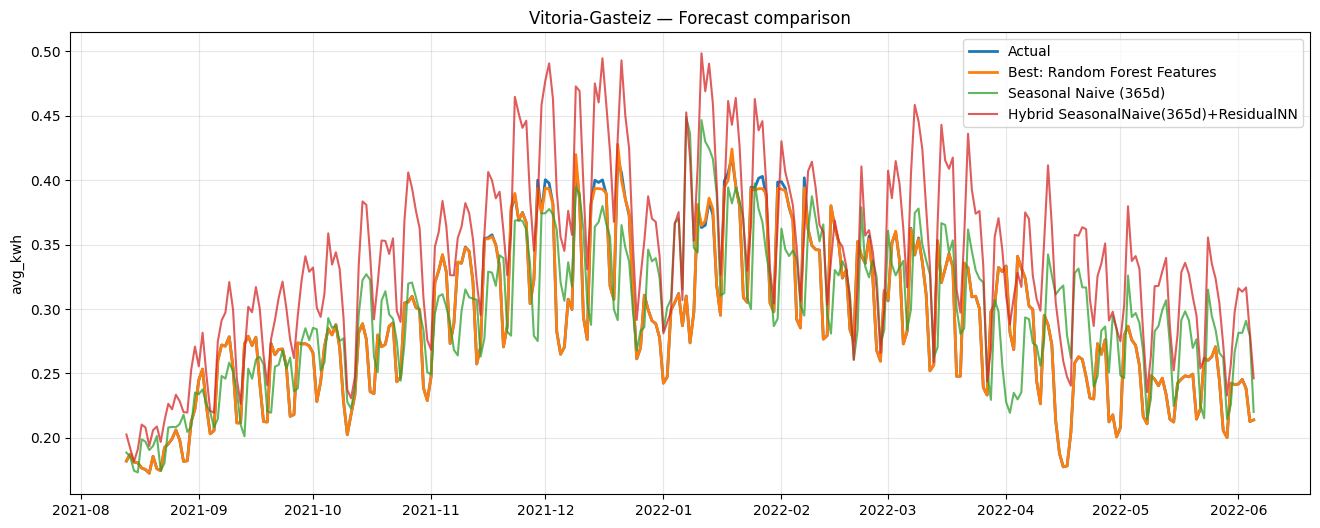

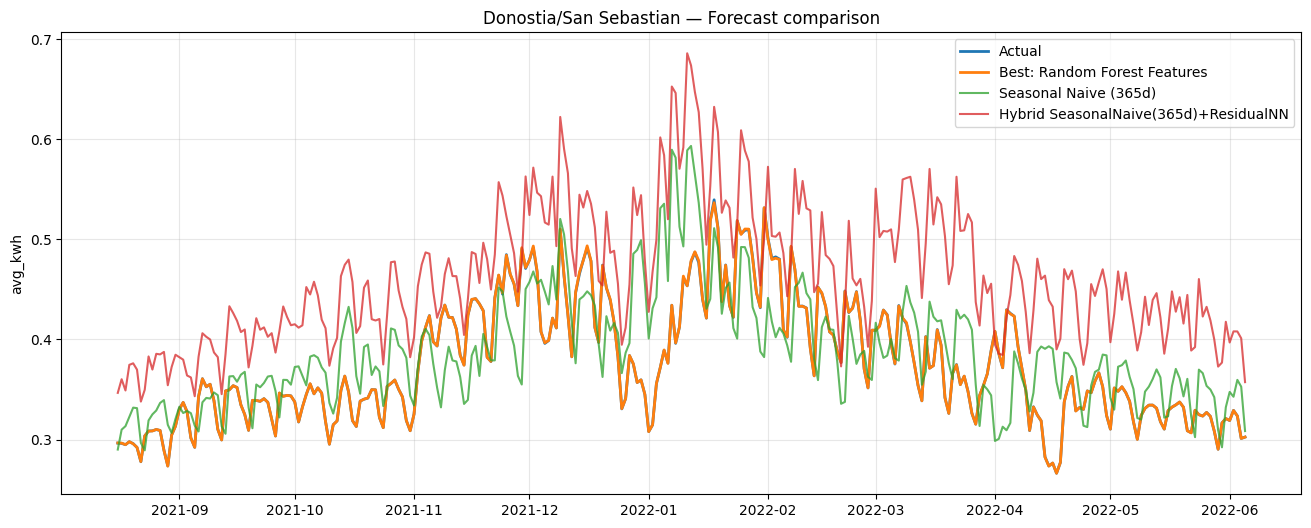

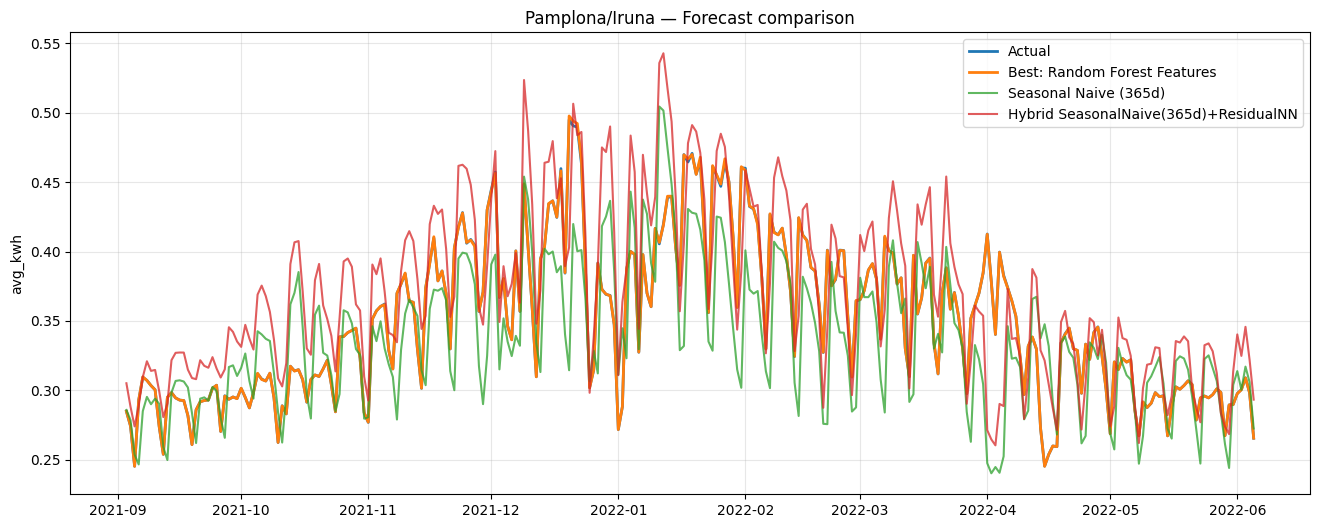

In [79]:
comparison_dfs = {}
summary_rows = []

for group in GROUPS_TO_FORECAST:
    comp = pd.DataFrame([v['metrics'] for v in all_results[group].values()]).set_index('Model').sort_values('RMSE')
    comparison_dfs[group] = comp
    print(f'\n{"="*100}\nFINAL COMPARISON — {group}\n{"="*100}')
    display(comp.round(4))

    best = comp.iloc[0]
    baseline_names = [i for i in comp.index if i == 'Naive' or i.startswith('Seasonal Naive') or i.startswith('Rolling')]
    best_baseline = comp.loc[baseline_names].sort_values('RMSE').iloc[0]
    summary_rows.append({
        GROUP_COL: group,
        'Best model': best.name,
        'Best RMSE': best['RMSE'],
        'Best baseline': best_baseline.name,
        'Baseline RMSE': best_baseline['RMSE'],
        'Improvement vs baseline (%)': (best_baseline['RMSE'] - best['RMSE']) / best_baseline['RMSE'] * 100
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))

for group in GROUPS_TO_FORECAST:
    test = series_data[group]['test'][TARGET_COL]
    best_model = comparison_dfs[group].index[0]
    plt.figure(figsize=(16, 6))
    plt.plot(test.index, test.values, label='Actual', linewidth=2)
    plt.plot(all_results[group][best_model]['pred'].index, all_results[group][best_model]['pred'].values, label=f'Best: {best_model}', linewidth=2)
    for name, data in all_results[group].items():
        if name.startswith('Seasonal Naive') or name.startswith('Hybrid'):
            plt.plot(data['pred'].index, data['pred'].values, label=name, alpha=0.75)
    plt.title(f'{group} — Forecast comparison')
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 12. Save outputs

In [80]:
OUTPUT_DIR = BASE_PATH / 'forecasting_model_results_365d_seasonality_avg_kwh_per_user'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUTPUT_DIR / 'summary_results.csv'
summary_df.to_csv(summary_path, index=False)
print('Saved summary:', summary_path)

for group, comp in comparison_dfs.items():
    safe = str(group).replace('/', '_').replace(' ', '_')
    comp.to_csv(OUTPUT_DIR / f'{safe}_metrics.csv')
    pred_df = pd.DataFrame(index=series_data[group]['test'].index)
    pred_df['actual'] = series_data[group]['test'][TARGET_COL]
    for model_name, data in all_results[group].items():
        pred_df[model_name] = data['pred']
    pred_df.to_csv(OUTPUT_DIR / f'{safe}_predictions.csv')
print('Done.')


Saved summary: C:\Users\GONCA\Desktop\Iscte\MCD\Theses\forecasting_model_results_365d_seasonality_avg_kwh_per_user\summary_results.csv
Done.


> Thesis text suggestion: The hybrid architecture decomposes the forecasting problem into a deterministic seasonal component and a non-linear residual component. The seasonal component is estimated with a seasonal naive rule, which is a strong baseline for daily electricity consumption because it directly preserves repeated demand patterns. The residual series, defined as the difference between observed consumption and the seasonal naive estimate, is then modelled using a neural network with calendar, lag, rolling, holiday, bridge-day, and municipality-normalised features. The final forecast is obtained by adding the predicted residual to the seasonal naive component.